In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [7]:
narrow_df = pd.read_csv("../../events/gw/gw_params_narrow.dat", sep=" ")
kn_params = pd.read_csv("../../events/kilonova/kn_params_narrow.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")

In [6]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(narrow_df["prompt_collapse"]==1)/narrow_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 7/637, 0.011,  0.09623246050160203


In [4]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -1.3973387390349703
zeta quantile:  0.23703551071571138


In [5]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  24.096 334.603


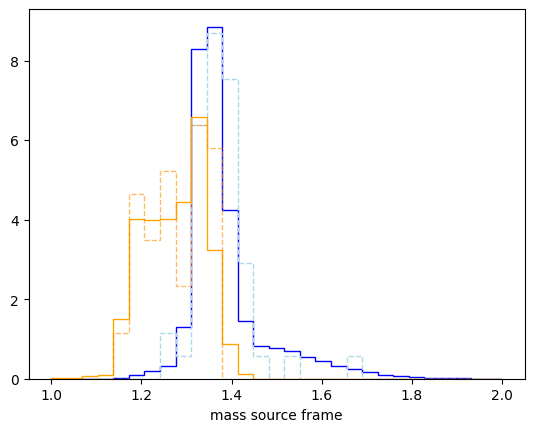

In [9]:
bins = np.linspace(1, 2, 30)

plt.hist(narrow_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(narrow_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

(array([3.99469897e-05, 9.98674742e-05, 4.19443391e-04, 2.13716395e-03,
        1.83756152e-02, 5.03931275e-02, 4.77765996e-02, 7.09059066e-02,
        5.26920767e-01, 1.09073258e+00]),
 array([-6.12588047, -5.57272225, -5.01956403, -4.4664058 , -3.91324758,
        -3.36008935, -2.80693113, -2.25377291, -1.70061468, -1.14745646,
        -0.59429823]),
 [<matplotlib.patches.Polygon at 0x7f93e559b1d0>])

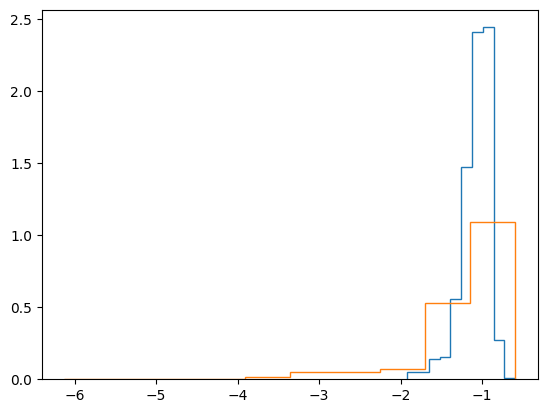

In [9]:
plt.hist(log10_mej_wind, histtype="step", density=True)
plt.hist(kn_params["log10_mej_wind"], histtype="step", density=True)

(array([9.83327679e-03, 1.38976979e-02, 2.26820918e-02, 3.74975622e-02,
        6.85707168e-02, 1.74507885e-01, 2.17118752e-01, 2.24329821e-01,
        2.07809916e-01, 1.47236931e-01, 1.80932293e-02, 5.50663500e-03,
        6.81773858e-03, 8.65328358e-03, 1.24554839e-02, 2.16332089e-02,
        3.76286725e-02, 6.84396065e-02, 1.68214588e-01, 2.27869801e+00,
        6.81668969e+00, 6.32738584e-01, 3.06142684e-01, 1.96665536e-01,
        1.13148238e-01, 3.51375757e-02, 1.70443464e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 array([-4.      , -3.915625, -3.83125 , -3.746875, -3.6625  , -3.578125,
        -3.49375 , -3.409375, -3.325   , -3.240625, -3.15625 , -3.071875,
        -2.9875  , -2.903125, -2.81875 , -2.734375, -2.65    , -2.565625,
        -2.48125 , -2.396875, -2.3125  , -2.228125, -2.14375 , -2.059375,
        -1.975   , -1.890625, -1.80625 , -1.721875, -1.6375  , -1.553125,
        -1.46875 , -1.384375, -1.3     ]),
 [<matplo

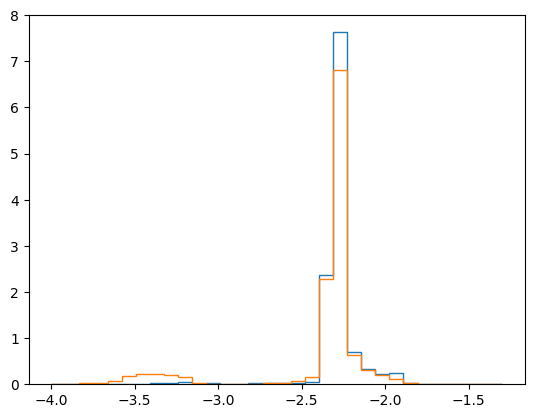

In [8]:
bins= np.linspace(-4, -1.3, 33)

plt.hist(events["log10_mej_dyn"], histtype="step", density=True, bins=bins)
plt.hist(kn_params["log10_mej_dyn"], histtype="step", density=True, bins=bins)